In [1]:
from util.util import *
from util.param import *
from util.util import *
from util.util_montage import *
import importlib

In [2]:
debug = False

In [3]:
# Hardcoded path for easier running
folder_path = "./data" # The data is stored here (.../condensate and .../RNA w/ ... being dataset subfolders)
img_path = "./result/img" # Images are saved here
result_path = "./result" # Calculation results are stored here

os.makedirs(img_path, exist_ok=True)

# Look up all subfolders in the data folder
subfolders = [f.path for f in os.scandir(folder_path) if f.is_dir() and not f.name.startswith('.')]
subfolders.sort()  # Sort the subfolders alphabetically

print(f"Found {len(subfolders)} subfolders in the data folder.")
i = 0
for subfolder in subfolders:
    print(f"    {i}: {subfolder.split('/')[-1]}")
    i += 1

Found 10 subfolders in the data folder.
    0: 2x_4EGI1
    1: 2x_CHX
    2: 2x_Har
    3: 2x_puro
    4: THOR_1x
    5: THOR_2x
    6: THORdel_2x
    7: THORdelta_1x
    8: mRNA-1x
    9: mRNA_2x


In [4]:
# Change this index to select different subfolders
index = 9
legend_bool = True
overwrite_trace_output = False

data_path = subfolders[index]
data_name = data_path.split("/")[-1]
print(f"Selected data for {data_name} in folder: {data_path}")

Selected data for mRNA_2x in folder: ./data/mRNA_2x


In [5]:
file_pairs = find_matching_files(data_path)

if not file_pairs:
    if debug:
        print("❌ No matching file pairs found!")
    pass
else:
    if debug:
        print(f"📂 Loading {len(file_pairs)} experiment datasets...")
    
    all_tracks = []
    all_condensates = []
    
    for rna_path, condensate_path, exp_name in track(file_pairs, description="Loading datasets"):
        df_tracks, df_condensates = load_dataset_pair(rna_path, condensate_path, exp_name)
        
        if df_tracks is not None and df_condensates is not None:
            all_tracks.append(df_tracks)
            all_condensates.append(df_condensates)
    
    if all_tracks and all_condensates:
        # Combine all datasets
        df_tracks_combined = pd.concat(all_tracks, ignore_index=True)
        df_condensates_combined = pd.concat(all_condensates, ignore_index=True)

        if debug:
            print(f"✅ Successfully loaded and combined:")
            print(f"   - {len(df_tracks_combined)} total track points")
            print(f"   - {len(df_condensates_combined)} total condensate entries")
            print(f"   - {df_tracks_combined['experiment'].nunique()} experiments")

        # Display summary statistics
        if debug:
            print("\n📊 Dataset Summary:")
        for exp in df_tracks_combined['experiment'].unique():
            exp_tracks = df_tracks_combined[df_tracks_combined['experiment'] == exp]
            exp_condensates = df_condensates_combined[df_condensates_combined['experiment'] == exp]
            if debug:
                print(f"   {exp}: {exp_tracks['trackID'].nunique()} tracks, "
                      f"{len(exp_condensates)} condensate entries")
    else:
        if debug:
            print("❌ No valid datasets were loaded successfully")
        pass

if debug:
    print("\n🎉 Data loading complete!")

Output()

## Minimum distance calculation from RNA to the boundary of condensates

In [6]:
print("🔄 Calculating distances from RNA to condensate boundaries...")

from shapely.geometry import Point, Polygon
from shapely.strtree import STRtree

### Optimized distance calculation using spatial index
output_csv = os.path.join(result_path, f"trace_csv/all/{data_name}_rna_condensate_distances.csv")

def calculate_rna_condensate_distances(df_tracks_combined,
                                       df_condensates_combined,
                                       output_csv,
                                       overwrite_save=False,
                                       um_per_pixel=um_per_pixel,
                                       s_per_frame=s_per_frame,
                                       condensate_detection_threshold=2,
                                       ):
    """
    Calculates the signed distance from RNA tracks to the nearest condensate boundary.
    If a track point is found inside a condensate, it "locks" to that condensate for subsequent frames.

    Args:
        df_tracks_combined (pd.DataFrame): DataFrame with combined track data.
        df_condensates_combined (pd.DataFrame): DataFrame with combined condensate data.
        output_csv (str): Path to save the output CSV file.
        um_per_pixel (float): Conversion factor from pixels to micrometers.
        s_per_frame (float): Conversion factor from frames to seconds.

    Returns:
        pd.DataFrame: DataFrame with calculated distances.
    """
    # Check if output CSV already exists
    if overwrite_save is False:
        if os.path.exists(output_csv):
            print(f"⚠️ Output CSV '{output_csv}' already exists. Skipping distance calculation to avoid overwriting.")
            return pd.read_csv(output_csv)

    if df_tracks_combined.empty or df_condensates_combined.empty:
        print("❌ Combined datasets are empty. Skipping distance calculation.")
        return pd.DataFrame()

    records = []
    # Process each experiment separately
    unique_experiments = df_tracks_combined['experiment'].unique()
    unique_experiments.sort()
    print(f"  • Found {len(unique_experiments)} unique experiments to process.")
    
    for exp_idx, exp in enumerate(unique_experiments):
        print(f"  • Processing experiment: {exp} ({exp_idx + 1}/{len(unique_experiments)})")
        
        # Filter data for the current experiment
        condensates_exp = df_condensates_combined[df_condensates_combined['experiment'] == exp]
        tracks_exp = df_tracks_combined[df_tracks_combined['experiment'] == exp]

        # Pre-process condensates for all frames in the experiment
        condensates_by_frame = {}
        for frame, group in condensates_exp.groupby('frame'):
            shapely_polygons = []
            for cnt_str in group['contour_coord']:
                bx, by = parse_contour_string(cnt_str)
                if len(bx) >= 3:
                    poly = Polygon(zip(bx, by))
                    if not poly.is_valid:
                        poly = poly.buffer(0)
                    if not poly.is_empty:
                        shapely_polygons.append(poly)
            
            if shapely_polygons:
                condensates_by_frame[frame] = {
                    'polygons': shapely_polygons,
                    'index': STRtree(shapely_polygons)
                }

        # Group tracks by trackID
        tracks_by_id = tracks_exp.groupby('trackID')

        # Iterate through each track in the experiment
        for track_id, track_df in tqdm(tracks_by_id, desc=f"    ↳ Tracks in {exp}"):
            locked_condensate = None # Initialize locked condensate as None
            
            # Sort track by time
            track_df = track_df.sort_values('t')

            for _, row in track_df.iterrows():
                frame = row['t']
                point = Point(row['x'], row['y'])
                min_dist = np.nan
                
                # If locked, calculate distance to the locked condensate
                if locked_condensate is not None:
                    # Check if the locked condensate still exists in the current frame
                    # This simple check assumes condensate identity is maintained by location.
                    # A more robust method would need condensate tracking.
                    if frame in condensates_by_frame:
                        spatial_index = condensates_by_frame[frame]['index']
                        polygons = condensates_by_frame[frame]['polygons']
                        
                        nearest_poly_idx = spatial_index.nearest(point)
                        if nearest_poly_idx is not None:
                            candidate_poly = polygons[nearest_poly_idx]
                            if candidate_poly.distance(locked_condensate) <= condensate_detection_threshold: # 2 frames tolerance
                                locked_condensate = candidate_poly # Update to current frame's polygon
                            else:
                                nearest_poly_to_locked_index = spatial_index.nearest(locked_condensate.centroid)
                                if nearest_poly_to_locked_index is not None:
                                    candidate_poly_to_locked = polygons[nearest_poly_to_locked_index]
                                    if candidate_poly_to_locked.distance(locked_condensate) <= condensate_detection_threshold:
                                        locked_condensate = candidate_poly_to_locked
                                        
                    min_dist = point.distance(locked_condensate.boundary)
                    if locked_condensate.contains(point):
                        min_dist = -min_dist

                else: # If locked condensate is None
                    # If not locked, find the nearest condensate
                    if frame in condensates_by_frame:
                        spatial_index = condensates_by_frame[frame]['index']
                        polygons = condensates_by_frame[frame]['polygons']
                        nearest_poly_idx = spatial_index.nearest(point)
                        if nearest_poly_idx is not None:
                            nearest_poly = polygons[nearest_poly_idx]
                            min_dist = point.distance(nearest_poly.boundary)
                            
                            if nearest_poly.contains(point):
                                min_dist = -min_dist
                                locked_condensate = nearest_poly # Lock onto this condensate

                if not np.isnan(min_dist):
                    dist_um = min_dist * um_per_pixel
                    contour_area = locked_condensate.area if locked_condensate is not None else np.nan
                    contour_coords = locked_condensate.centroid if locked_condensate is not None else np.nan
                    records.append({
                        'experiment': exp,
                        'trackID': track_id,
                        't': frame * s_per_frame,
                        'distance_um': dist_um,
                        'contour_area': contour_area,
                        'contour_coords': contour_coords
                    })

    # Create DataFrame and save
    df_distances = pd.DataFrame(records)
    if not df_distances.empty:
        df_distances.to_csv(output_csv, index=False)
        print(f"✅ Saved distances to: {output_csv}")
    else:
        print("No records were generated, CSV not saved.")
        
    return df_distances

# Call the function
df_distances = calculate_rna_condensate_distances(
    df_tracks_combined, 
    df_condensates_combined,
    output_csv,
    overwrite_save=overwrite_trace_output
)

print("🔄 Generating distance vs. time plots for each experiment...")

# Load distances if not in memory
try:
    df_distances = df_distances
except NameError:
    df_distances = pd.read_csv(output_csv)

# Identify first dwell per track per experiment
first_dwell = df_distances[df_distances['distance_um'] <= 0] \
    .groupby(['experiment', 'trackID'])['t'] \
    .min() \
    .reset_index() \
    .rename(columns={'t': 't_dwell'})

print(f"  • Found {len(first_dwell)} first-dwell events across all experiments")

# Merge dwell times back into distances
df_plot = df_distances.merge(first_dwell, on=['experiment', 'trackID'], how='left')

# Keep only points at and after first dwell
df_plot = df_plot[df_plot['t'] >= df_plot['t_dwell']]

🔄 Calculating distances from RNA to condensate boundaries...
⚠️ Output CSV './result/trace_csv/all/mRNA_2x_rna_condensate_distances.csv' already exists. Skipping distance calculation to avoid overwriting.
🔄 Generating distance vs. time plots for each experiment...
  • Found 8724 first-dwell events across all experiments


In [7]:
df_plot = df_plot.sort_values(['experiment', 'trackID', 't']).reset_index(drop=True)
df_plot

,experiment,trackID,t,distance_um,contour_area,contour_coords,t_dwell
0,20220508-FLmRNA_2x_FOV,6,0.0,-0.032633,22.0,POINT (91.6590909090909 247.25),0.0
1,20220508-FLmRNA_2x_FOV,6,0.1,-0.008804,22.5,POINT (91.17037037037038 247.02962962962965),0.0
2,20220508-FLmRNA_2x_FOV,6,0.2,-0.030452,20.0,POINT (91.38333333333334 247.31666666666666),0.0
3,20220508-FLmRNA_2x_FOV,6,0.3,-0.007836,21.5,POINT (91.42635658914729 247.15503875968992),0.0
4,20220508-FLmRNA_2x_FOV,6,0.4,-0.122833,23.0,POINT (91.5 247.24637681159422),0.0
...,...,...,...,...,...,...,...
437968,20220508-FLmRNA_2x_FOV-9,4701,18.3,-0.035975,17.0,POINT (201.2843137254902 298.2254901960784),17.4
437969,20220508-FLmRNA_2x_FOV-9,4701,18.4,-0.109002,20.0,POINT (201 298.3),17.4
437970,20220508-FLmRNA_2x_FOV-9,4701,18.5,-0.092475,14.0,POINT (201.21428571428572 298.1547619047619),17.4
437971,20220508-FLmRNA_2x_FOV-9,4701,18.6,-0.121428,13.5,POINT (201.2469135802469 298.2716049382716),17.4


`1037` is interesting

In [8]:
# Create separate plot for each experiment
experiments = df_plot['experiment'].unique()
experiments.sort()

from scipy.signal import find_peaks # For peak detection

df_filtered = pd.DataFrame()  # To collect tracks with peak detection errors
df_error = pd.DataFrame()  # To collect tracks with peak detection errors
df_outlier = pd.DataFrame()  # To collect tracks with peak detection errors

# Maximum jump per frame is 3 pixel frames 
max_jump = 3 * um_per_pixel / s_per_frame

error_count = 0

# Filter out tracks with huge jumps in distance derivative (potential tracking errors)
for exp in experiments:
    exp_data = df_plot[df_plot['experiment'] == exp]
    for track in np.sort(exp_data['trackID'].unique()):
        track_data = exp_data[exp_data['trackID'] == track]
        
        x = np.array(track_data['t'] - track_data['t_dwell'])
        y = np.array(track_data['distance_um'])
        
        dx = np.diff(x)
        dy = np.diff(y)
        derivative = dy / dx
        
        if any(abs(derivative) > max_jump):
            error_count += 1
            df_error = pd.concat([df_error, track_data], ignore_index=True)
        else:
            df_filtered = pd.concat([df_filtered, track_data], ignore_index=True)
            
        try:
            peaks, _ = find_peaks(y,
                                height=0.4, # only consider peaks above 0.4 um (arbitrary)
                                prominence=0.7) # only consider peaks with at least 0.7 um prominence (arbitrary)
            if len(peaks) >= 1:
                error_count += 1
                df_error = pd.concat([df_error, track_data], ignore_index=True)
        except Exception as e:
            print(f"Error finding peaks for track {track} in {exp}: {e}")
            pass
        
        if 'derivative' in locals() and any(abs(derivative) > max_jump):
            df_outlier = pd.concat([df_outlier, track_data], ignore_index=True)
            
plot_trajectories = False

if plot_trajectories:
    print(f"  • Creating {len(experiments)} separate plots...")
    for exp in experiments:
        print(f"    → Processing experiment: {exp}")
        
        # Filter data for this experiment
        exp_data = df_plot[df_plot['experiment'] == exp]
        
        if exp_data.empty:
            print(f"      ⚠️ No dwell data found for {exp}, skipping...")
            continue
        
        # Create figure for this experiment
        fig, ax = plt.subplots(2, 1, figsize=(10, 14))
        
        track_count = 0
        # Plot each track in this experiment
        for track in np.sort(exp_data['trackID'].unique()):
            # if track_count >= 10:
            #     print(f"      ⚠️ More than 10 tracks in {exp}, limiting to first 10 for clarity.")
            #     break
            print(f"      • Plotting track {int(track)}...", end="\r")
            track_data = exp_data[exp_data['trackID'] == track]
            
            # Use find_peaks to highlight peaks with huge prominence
            x = np.array(track_data['t'] - track_data['t_dwell'])
            y = np.array(track_data['distance_um'])
            
            dx = np.diff(x)
            dy = np.diff(y)
            # Calculate derivative (dy/dx)
            derivative = dy / dx
            
            # Use find_peaks to highlight peaks with huge prominence
            try:
                peaks, _ = find_peaks(y,
                                    height=0.4, # only consider peaks above 0.4 um (arbitrary)
                                    prominence=0.7) # only consider peaks with at least 0.7 um prominence (arbitrary)
                # ax.plot(x[peaks], y[peaks], "x", color='red')
                # Continue to the next track if peak is found
                if len(peaks) >= 1:
                    error_count += 1
                    df_error = pd.concat([df_error, track_data], ignore_index=True)
                    continue

            except Exception as e:
                print(f"      ❌ Error finding peaks for track {track} in {exp}: {e}")
                pass
            
            # Use different colors for better visibility
            ax[0].plot(x, y,
                    alpha=0.5,
                    linewidth=1.5,
                    label=f"Track {int(track)}")

            ax[0].scatter(x, y,
                    s=10,
                    alpha=0.7,
                    zorder=10)

            # Plot the derivative if it exists
            if 'derivative' in locals():
                ax[1].plot(x[:-1], derivative, alpha=0.5, linewidth=1.5, label=f"Track {int(track)}")
                
                if any(abs(derivative) > max_jump):
                    df_outlier = pd.concat([df_outlier, track_data], ignore_index=True)
            
            df_filtered = pd.concat([df_filtered, track_data], ignore_index=True)
            track_count += 1
        
        ax[0].axhline(0, color='gray', linestyle='--', linewidth=1, zorder=12)
        
        ax[1].axhline(max_jump, color='orange', linestyle='--', linewidth=1, zorder=12)
        ax[1].axhline(-max_jump, color='orange', linestyle='--', linewidth=1, zorder=12)

        ax[0].set_xlabel("")
        ax[0].set_ylabel("Distance to condensate boundary (μm)", fontsize=12, fontweight='bold')
        ax[0].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
        
        ax[1].set_xlabel("Time since first dwell (s)", fontsize=12, fontweight='bold')
        ax[1].set_ylabel("Distance Derivative (μm/s)", fontsize=12, fontweight='bold')
        
        
        ax[0].set_title(f"RNA Distance from Condensate Boundary Over Time\n{exp} ({track_count} tracks)", 
                    fontsize=14, fontweight='bold')
        ax[0].grid(True, linestyle='--', alpha=0.3)

        # # Add legend with reasonable limit
        # max_legend_entries = 15
        # if track_count <= max_legend_entries:
        #     ax[0].legend(fontsize=9, ncol=2, loc='upper right', framealpha=0.9)
        # else:
        #     print(f"      ⚠️ Too many tracks ({track_count}) for legend in {exp}")
        
        # Add summary statistics as text box
        max_dist = exp_data['distance_um'].max()
        mean_dist = exp_data['distance_um'].mean()
        textstr = f'Max distance: {max_dist:.2f} μm\nMean distance: {mean_dist:.2f} μm'
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
        
        ax[0].text(0.02, 0.98, textstr, transform=ax[0].transAxes, fontsize=10, verticalalignment='top', bbox=props)
        
        plt.tight_layout()
        
        # Save with experiment-specific filename
        safe_exp_name = exp.replace(" ", "_").replace("/", "_").replace("\\", "_")
        output_png = os.path.join(img_path, f"distance_vs_time_{safe_exp_name}.png")
        fig.savefig(output_png, dpi=300, bbox_inches='tight')
        print(f"      ✅ Saved: distance_vs_time_{safe_exp_name}.png")
        
        plt.show()
        # plt.close()  # Close to free memory

In [9]:
if not df_outlier.empty:
    n_outliers = df_outlier['trackID'].nunique()
    print(f"🔔 Found {n_outliers} ({n_outliers/len(df_outlier)*100:.1f}%) tracks with outlier jumps exceeding {max_jump:.2f} μm.")

🔔 Found 858 (1.8%) tracks with outlier jumps exceeding 3.51 μm.


In [10]:
df_outlier

,experiment,trackID,t,distance_um,contour_area,contour_coords,t_dwell
0,20220508-FLmRNA_2x_FOV,21,5.6,-0.001179,24.0,POINT (211.63888888888889 255.47916666666666),5.6
1,20220508-FLmRNA_2x_FOV,21,5.7,0.113581,23.0,POINT (211.47826086956522 255.3768115942029),5.6
2,20220508-FLmRNA_2x_FOV,21,5.8,-0.011673,22.5,POINT (211.71851851851852 255.2962962962963),5.6
3,20220508-FLmRNA_2x_FOV,21,5.9,0.104159,21.0,POINT (211.38095238095238 255.4047619047619),5.6
4,20220508-FLmRNA_2x_FOV,21,6.0,0.093107,3.0,POINT (215 256.77777777777777),5.6
...,...,...,...,...,...,...,...
46886,20220508-FLmRNA_2x_FOV-9,4701,18.3,-0.035975,17.0,POINT (201.2843137254902 298.2254901960784),17.4
46887,20220508-FLmRNA_2x_FOV-9,4701,18.4,-0.109002,20.0,POINT (201 298.3),17.4
46888,20220508-FLmRNA_2x_FOV-9,4701,18.5,-0.092475,14.0,POINT (201.21428571428572 298.1547619047619),17.4
46889,20220508-FLmRNA_2x_FOV-9,4701,18.6,-0.121428,13.5,POINT (201.2469135802469 298.2716049382716),17.4


In [11]:
# ### Added section to create a separate plot for tracks with peak detection errors
# # Create the plot for tracks with peak detection errors
# if not df_outlier.empty:
#     all_tracks = []
#     for exp in df_outlier['experiment'].unique():
#         exp_data = df_outlier[df_outlier['experiment'] == exp]
#         for track in exp_data['trackID'].unique():
#             all_tracks.append((exp, track))

#     plot_count = 0
#     for i in range(0, len(all_tracks), 30):
#         plot_count += 1
#         chunk_of_tracks = all_tracks[i:i + 30]
        
#         fig, ax = plt.subplots(figsize=(10, 7))
        
#         # Get unique experiment names for this chunk for the filename
#         chunk_experiments = set()

#         for exp, track_id in chunk_of_tracks:
#             track_data = df_outlier[(df_outlier['experiment'] == exp) & (df_outlier['trackID'] == track_id)]
#             x = np.array(track_data['t'] - track_data['t_dwell'])
#             y = np.array(track_data['distance_um'])
#             ax.plot(x, y, alpha=0.5, linewidth=1.5, label=f"Track {track_id}")
#             chunk_experiments.add(exp)

#         ax.set_xlabel("Time since first dwell (s)", fontsize=12, fontweight='bold')
#         ax.set_ylabel("Distance to condensate boundary (μm)", fontsize=12, fontweight='bold')
#         ax.set_title(f"RNA Distance from Condensate Boundary Over Time\n(Outlier Tracks, Part {plot_count})", 
#                     fontsize=14, fontweight='bold')
#         ax.grid(True, linestyle='--', alpha=0.3)
        
#         plt.tight_layout()
        
#         # Convert set to a sorted list to get the first and last experiment names
#         sorted_chunk_experiments = sorted(list(chunk_experiments))
#         chunk_experiments_for_filename = (sorted_chunk_experiments[0], sorted_chunk_experiments[-1]) if sorted_chunk_experiments else []
        
#         # Create a safe filename for the plot
#         error_exp_names = "_".join(sorted([str(e).replace(" ", "_").replace("/", "_").replace("\\", "_") for e in chunk_experiments_for_filename]))
        
#         # Make sure the outliers directory exists
#         outlier_img_path = os.path.join(img_path, "outliers")
#         os.makedirs(outlier_img_path, exist_ok=True)
        
#         error_output_png_filename = f"outliers_{error_exp_names}_part_{plot_count}.png"
#         output_png = os.path.join(outlier_img_path, error_output_png_filename)
        
#         fig.savefig(output_png, dpi=300, bbox_inches='tight')
#         print(f"      ✅ Saved: {error_output_png_filename}")

#         plt.close()  # Close to free memory
    
#     # Plot the snapshot
#     # Create snapshots for outlier tracks
#     snapshot_save_path = os.path.join(img_path, "outliers", "snapshots")
#     os.makedirs(snapshot_save_path, exist_ok=True)
    
#     snapshot_tracks = all_tracks[:2]
    
#     for exp, track_id in snapshot_tracks:
#         print(f"  • Creating snapshot for outlier track: {exp}, Track ID: {track_id}")
        
#         # Get the full track data from the combined dataframe
#         track_df = df_tracks_combined[(df_tracks_combined['experiment'] == exp) & (df_tracks_combined['trackID'] == track_id)]
        
#         # Get the condensate data for the experiment
#         condensate_df = df_condensates_combined[df_condensates_combined['experiment'] == exp]
        
#         # Get the outlier trace data
#         trace_df = df_outlier[(df_outlier['experiment'] == exp) & (df_outlier['trackID'] == track_id)]
        
#         if track_df.empty or condensate_df.empty or trace_df.empty:
#             print(f"      ⚠️ Could not find all necessary data for outlier track {track_id} in {exp}. Skipping snapshot.")
#             continue
            
#         # Analyze interactions
#         try:
#             experiment_result = analyze_interactions(track_df, condensate_df, proximity_threshold=1)
#         except Exception as e:
#             print(f"      ❌ Error analyzing interactions for outlier track {track_id} in {exp}: {e}")
#             continue

#         # Create the snapshot
#         try:
#             safe_exp_name = exp.replace(" ", "_").replace("/", "_").replace("\\", "_")
#             snapshot_filename = f"snapshot_{safe_exp_name}_track_{track_id}.png"
#             save_path = os.path.join(snapshot_save_path, snapshot_filename)
#             plot_trajectory_snapshots(df_tracks=track_df,
#                                       df_condensates=condensate_df,
#                                       exp_results=experiment_result,
#                                       trace_df=trace_df,
#                                       window_size_um=1.0,
#                                       um_per_pixel=um_per_pixel,
#                                       gradient_color=True,
#                                       show_interaction=True,
#                                       show_condensate_movements=True,
#                                       distance_by_interaction=True,
#                                       condensate_detection_threshold=2,
#                                       save_path=save_path
#                                       )
#             print(f"      ✅ Saved snapshot: {snapshot_filename}")
#         except Exception as e:
#             print(f"      ❌ Error creating snapshot for outlier track {track_id} in {exp}: {e}")
            
#     print("🎉 Finished creating outlier snapshots.")

In [12]:
tracks_to_plot = []
for exp in df_filtered['experiment'].unique():
    exp_data = df_filtered[df_filtered['experiment'] == exp]
    for track in exp_data['trackID'].unique():
        tracks_to_plot.append((exp, track))

In [13]:
# Plot the snapshot
# Create snapshots for outlier tracks
snapshot_save_path = os.path.join(img_path, "representative_tracks")
os.makedirs(snapshot_save_path, exist_ok=True)

In [20]:
def plot_a_trajectory(track_df,
                    df_condensates,
                    exp_results,
                    trace_df,
                    t_max: float = 3.0,
                    title: str = "",
                    save_path: str = "",
                    um_per_pixel: float = 0.1,  
                    window_size_um: float = 5.0,  
                    scale_bar_um: float = 1.0, 
                    gradient_color: bool = False,
                    show_interaction: bool = False,
                    show_condensate_movements: bool = False,
                    distance_by_interaction: bool = False,
                    condensate_detection_threshold: float = 2.0,
                    window_center: str = "condensate"
                    ):
    """
    Creates a single, zoomed-in snapshot for one RNA track interacting with one condensate.
    """
    # Parameters for the figure layout
    window_size_px = window_size_um / um_per_pixel  
    half_window_px = window_size_px / 2
    
    max_fps = 20
    num_points = max_fps * 10 
    
    exp, result = list(exp_results.items())[0]
    num_col = 2
    # print(f"Length of exp_results: {num_col}")
    experiment = list(exp_results.keys())[0]
    final_frame = result['final_frame']
    
    # Check for interacting tracks
    interacting_tracks = result.get('interacting_tracks', [])
    if not interacting_tracks:
        print(f"❌ No interacting tracks found for {experiment}, skipping snapshot.")
        return
    
    # Obtain the track data
    track_data = track_df[(track_df['t'] <= final_frame)].sort_values('t')
    
    # Detect interactions
    # Assuming detect_RNA_condensate_interactions is available in your scope
    interaction_info = detect_RNA_condensate_interactions(track_data, 
                                                            df_condensates[df_condensates['experiment'] == experiment],
                                                            condensate_detection_threshold=condensate_detection_threshold)
    
    # Find the condensate center
    if 'nearest_condensate_id' in interaction_info.columns and not interaction_info['nearest_condensate_id'].isnull().all():
        first_interacting_condensate_id = interaction_info[interaction_info['is_interacting'] == True]['nearest_condensate_id'].iloc[0]
        shapely_contour_wkt = wkt.loads(interaction_info[interaction_info['nearest_condensate_id'] == first_interacting_condensate_id]['shapely_contour'].iloc[0])
        cx, cy = shapely_contour_wkt.exterior.xy
    else:
        cx, cy = 0, 0
        
    # --- FIXED SECTION: Calculate Zoom Window (Removed int casting for precision) ---
    if window_center == "RNA":
        min_x_track, max_x_track = track_data['x'].min(), track_data['x'].max()
        min_y_track, max_y_track = track_data['y'].min(), track_data['y'].max()
        
        center_x = (min_x_track + max_x_track) / 2
        center_y = (min_y_track + max_y_track) / 2
        
        max_length = max(max_x_track - min_x_track, max_y_track - min_y_track)
        # Ensure window fits the track
        current_half_window = max(half_window_px, (max_length / 2)) 
        
        zoom_xmin = center_x - current_half_window
        zoom_xmax = center_x + current_half_window
        zoom_ymin = center_y - current_half_window
        zoom_ymax = center_y + current_half_window
    else:
        min_x_cond, max_x_cond = np.min(cx), np.max(cx)
        min_y_cond, max_y_cond = np.min(cy), np.max(cy)
        
        min_x_track, max_x_track = track_data['x'].min(), track_data['x'].max()
        min_y_track, max_y_track = track_data['y'].min(), track_data['y'].max()
        
        center_x = (min(min_x_cond, min_x_track) + max(max_x_cond, max_x_track)) / 2
        center_y = (min(min_y_cond, min_y_track) + max(max_y_cond, max_y_track)) / 2
        
        # Keep as floats to ensure dx == dy exactly
        zoom_xmin = center_x - half_window_px
        zoom_xmax = center_x + half_window_px
        zoom_ymin = center_y - half_window_px
        zoom_ymax = center_y + half_window_px

    # Set up colors
    if gradient_color:
        color_map = plt.get_cmap('viridis')
        # Ensure we have enough colors if num_points is small/large
        n_p = max(num_points, len(track_data))
        frame_colors_map = [color_map(i / (n_p - 1)) for i in range(n_p)]
        # Fallback for simple indexing
        frame_colors = ["tab:blue" for _ in range(num_points)]
    else:
        frame_colors = ["tab:blue" for _ in range(num_points)]
        
    # Create figure
    fig, ax = plt.subplots(1, num_col, figsize=(num_col*5, 5), width_ratios=[1, 1])
    
    # ---------------- PLOT LEFT (Trajectory) ----------------
    
    # 1. Plot Condensate
    condensate_alpha = 0.2
    if show_condensate_movements:
        frame_list = interaction_info['frame'].values
        contour_list = interaction_info['shapely_contour'].values
        for i in range(len(contour_list)):
            try:
                shapely_poly = wkt.loads(contour_list[i])
                patch = MplPolygon(list(shapely_poly.exterior.coords), closed=True, fill=True, 
                                   edgecolor="#2E86AB", facecolor="#AED6F1", alpha=condensate_alpha, zorder=-1)
                ax[0].add_patch(patch)
            except:
                continue
    else:
        patch = MplPolygon(np.column_stack((cx, cy)), closed=True, fill=True, 
                           edgecolor="#2E86AB", facecolor="#AED6F1", alpha=condensate_alpha+0.3, zorder=1)
        ax[0].add_patch(patch)
    
    # 2. Plot Track
    if distance_by_interaction and gradient_color:
        x = interaction_info['x']
        y = interaction_info['y']
        
        ax[0].plot(x.iloc[0], y.iloc[0], marker='o', markersize=6, color=color_map(0), markerfacecolor='white', markeredgewidth=2)
        ax[0].plot(x.iloc[-1], y.iloc[-1], marker='s', markersize=5, color=color_map(1), markerfacecolor=color_map(1), markeredgewidth=1, alpha=0.8)
        
        for i in range(len(x) - 1):
            ax[0].arrow(x.iloc[i], y.iloc[i], x.iloc[i+1] - x.iloc[i], y.iloc[i+1] - y.iloc[i], head_width=0.05, head_length=0.05, lw=2, color=frame_colors_map[i], alpha=0.8)
    
    elif gradient_color and not distance_by_interaction:
        n_data = len(track_data)
        for i in range(n_data - 1):
            frame_idx = int(track_data['t'].iloc[i])
            # Safety check for index
            c = frame_colors_map[i] if i < len(frame_colors_map) else "tab:blue"
            ax[0].arrow(track_data['x'].iloc[i], track_data['y'].iloc[i], track_data['x'].iloc[i+1] - track_data['x'].iloc[i], track_data['y'].iloc[i+1] - track_data['y'].iloc[i], head_width=0.05, head_length=0.05, lw=1, color=c, alpha=0.8)

        ax[0].plot(track_data.iloc[0]['x'], track_data.iloc[0]['y'], marker='o', markersize=6, color=color_map(0), markerfacecolor='white', markeredgewidth=2)
        ax[0].plot(track_data.iloc[-1]['x'], track_data.iloc[-1]['y'], marker='s', markersize=5, color=color_map(1), markerfacecolor=color_map(1), markeredgewidth=1, alpha=0.8)
        
    else:
        # Gradient from white to red (standard)
        color_map_red = plt.get_cmap('plasma')
        n_data = 100
        fc = [color_map_red(i / (n_data - 1)) for i in range(n_data)]
        frame_alphas = np.linspace(0.3, 0.75, n_data)
        
        for i in range(n_data - 1):
            # ax[0].arrow(track_data['x'].iloc[i], track_data['y'].iloc[i],
            #             track_data['x'].iloc[i+1] - track_data['x'].iloc[i],
            #             track_data['y'].iloc[i+1] - track_data['y'].iloc[i],
            #             head_width=0.05, head_length=0.05, lw=2.5, color="#FF4D6D", alpha=0.6)
            
            # Temporarily only using one color for publication
            ax[0].plot(track_data['x'].iloc[i:i+2], track_data['y'].iloc[i:i+2], lw=3, c='#FF4D6D', alpha=0.6)
            # ax[0].arrow(track_data['x'].iloc[i], track_data['y'].iloc[i], track_data['x'].iloc[i+1] - track_data['x'].iloc[i], track_data['y'].iloc[i+1] - track_data['y'].iloc[i], head_width=0.05, head_length=0.05, lw=2.5, color='#FF4D6D', alpha=0.6)
            
            # ax[0].arrow(track_data['x'].iloc[i], track_data['y'].iloc[i], track_data['x'].iloc[i+1] - track_data['x'].iloc[i], track_data['y'].iloc[i+1] - track_data['y'].iloc[i], head_width=0.05, head_length=0.05, lw=3, color=fc[i], alpha=frame_alphas[i])
        
        ax[0].plot(track_data.iloc[0]['x'], track_data.iloc[0]['y'], marker='o', markersize=6, color=fc[-1], markerfacecolor='white', markeredgewidth=2)
        ax[0].plot(track_data.iloc[-1]['x'], track_data.iloc[-1]['y'], marker='X', markersize=8, color=fc[0], markerfacecolor="#D35400", markeredgewidth=1, alpha=0.8)
    
    # 3. Plot Interaction Vectors
    if show_interaction:
        distance_um = interaction_info['min_distance_to_condensate'] / um_per_pixel
        angle = interaction_info['angle_to_contour']
        x_trk, y_trk = track_data['x'], track_data['y']
        for i in range(len(x_trk)-1):
            start_point = (x_trk.iloc[i], y_trk.iloc[i])
            dx = distance_um.iloc[i] * np.cos((angle.iloc[i]))
            dy = distance_um.iloc[i] * np.sin((angle.iloc[i]))
            end_point = (start_point[0] + dx, start_point[1] + dy)
            # Use a default color if frame_colors isn't populated
            c_arrow = frame_colors[i] if i < len(frame_colors) else "black" 
            ax[0].arrow(start_point[0], start_point[1], end_point[0]-start_point[0], end_point[1]-start_point[1],
                    head_width=0.1, head_length=0.1, fc=c_arrow, ec=c_arrow, alpha=0.5)

    # 4. Scale Bar
    scale_bar_length_px = scale_bar_um / um_per_pixel
    # Anchor scale bar relative to the precise zoom limits
    scale_bar_x_start = zoom_xmax - ((zoom_xmax - zoom_xmin) * 0.25) # 25% from right
    scale_bar_y = zoom_ymin + ((zoom_ymax - zoom_ymin) * 0.05)       # 5% from bottom
    
    # Or keep original top-left logic, but using the float limits:
    scale_bar_x_start = zoom_xmax - (0.5 * window_size_px) 
    scale_bar_y = zoom_ymin + (0.075 * window_size_px)
    
    ax[0].plot([scale_bar_x_start, scale_bar_x_start + scale_bar_length_px], [scale_bar_y, scale_bar_y], lw=7, c="black")
    
    # --- FIXED SECTION: Apply Aspect Ratio and Limits ---
    ax[0].set_xlim(zoom_xmin, zoom_xmax)
    ax[0].set_ylim(zoom_ymin, zoom_ymax)
    ax[0].tick_params(axis='both', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
    
    # This combination forces the box to be a square and the data to be equal aspect
    ax[0].set_aspect('equal') 
    ax[0].set_box_aspect(1) 
    
    
    # ---------------- PLOT RIGHT (Distance vs Time) ----------------
    if gradient_color and not show_interaction:
        num_points_trace = len(trace_df)
        for i in range(num_points_trace - 1):
            # Safe frame indexing
            frame = int(trace_df['t'].iloc[i]*10)
            c = frame_colors_map[frame] if frame < len(frame_colors_map) else "grey"
            ax[1].plot(trace_df['t'].iloc[i:i+2], trace_df['distance_um'].iloc[i:i+2], lw=2, c=c, alpha=0.8)

    elif show_interaction:
        y_dist = interaction_info['min_distance_to_condensate']
        x_time = interaction_info['frame'] / 10.0 
        for i in range(len(x_time)-1):
            c = frame_colors[i] if i < len(frame_colors) else "tab:blue"
            ax[1].plot(x_time.iloc[i:i+2], y_dist.iloc[i:i+2], lw=2, c=c, alpha=0.8)    
        
        ax2 = ax[1].twinx()
        num_points_trace = len(trace_df)
        for i in range(num_points_trace - 1):
            ax2.plot(trace_df['t'].iloc[i:i+2], trace_df['distance_um'].iloc[i:i+2], lw=2, c='tab:red', alpha=0.5)            
        
        ylims = ax2.get_ylim()
        ax[1].set_ylim(ylims)
        ax2.tick_params(axis='y', labelcolor='tab:red', labelsize=10)
        ax2.set_ylabel("Distance (μm) by bulk analysis", color='tab:red', fontsize=12)
    else:
        ax[1].plot(trace_df['t'], trace_df['distance_um'], lw=2, c='grey', alpha=0.8)
    
    ax[1].set_xlabel("Time (s)", fontsize=12)
    ax[1].set_ylabel("Distance (μm)", fontsize=12)
    ax[1].tick_params(axis='both', which='major', labelsize=10)
    ax[1].axhline(y=0, color='gray', linestyle='--', lw=1)
    ax[1].set_xlim(0, trace_df['t'].max())
    # You might want to auto-scale Y or keep fixed
    ax[1].set_ylim(-0.5, 1.0) 

    if title:
        fig.suptitle(title, fontsize=16)
        
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=True)
    plt.show()

## Plot a representative trajectory

Creating snapshot for 20220508-FLmRNA_2x_FOV, Track ID: 164
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV
    ✅ 1/1 tracks interacting with 984 condensates


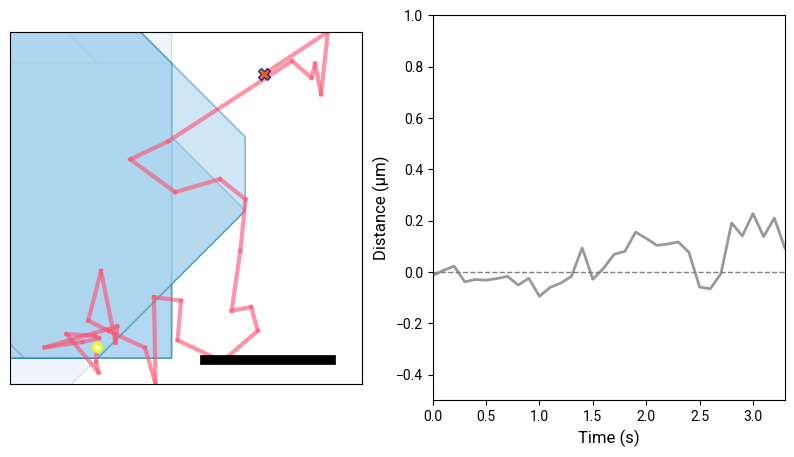

  ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV_track_164.svg


In [21]:
# indices = np.arange(0, len(tracks_to_plot))  # Example indices for the first 5 tracks
indices = [18]
track_to_plot = [tracks_to_plot[i] for i in indices]

for exp, track_id in track_to_plot:
    print(f"Creating snapshot for {exp}, Track ID: {track_id}")
    
    track_df = df_tracks_combined[(df_tracks_combined['experiment'] == exp) & (df_tracks_combined['trackID'] == track_id)]
    condensate_df = df_condensates_combined[df_condensates_combined['experiment'] == exp]
    trace_df = df_filtered[(df_filtered['experiment'] == exp) & (df_filtered['trackID'] == track_id)]
    
    if track_df.empty or condensate_df.empty or trace_df.empty:
        print(f"  ⚠️ Missing data for {exp}, Track ID: {track_id}. Skipping.")
        continue
    
    try:
        exp_results = analyze_interactions(track_df, condensate_df, proximity_threshold=1)
    except Exception as e:
        print(f"  ❌ Error analyzing interactions for {exp}, Track ID: {track_id}: {e}")
        continue
    
    safe_exp_name = exp.replace(" ", "_").replace("/", "_").replace("\\", "_")
    snapshot_filename = f"snapshot_{safe_exp_name}_track_{track_id}.svg"
    save_path = os.path.join(img_path, "representative_tracks", snapshot_filename)
    
    try:
        plot_a_trajectory(track_df=track_df,
                        df_condensates=condensate_df,
                        exp_results=exp_results,
                        trace_df=trace_df,
                        t_max=3.0,
                        # title=f"{exp} - Track {track_id}",
                        save_path=save_path,
                        um_per_pixel=um_per_pixel,
                        window_size_um=0.5,
                        scale_bar_um=0.2,
                        gradient_color=False,
                        show_interaction=False,
                        show_condensate_movements=True,
                        distance_by_interaction=True,
                        condensate_detection_threshold=2.0,
                        window_center="RNA"
                        )
        print(f"  ✅ Saved snapshot: {snapshot_filename}")
    except Exception as e:
        print(f"  ❌ Error creating snapshot for {exp}, Track ID: {track_id}: {e}")

In [16]:
df_filtered

,experiment,trackID,t,distance_um,contour_area,contour_coords,t_dwell
0,20220508-FLmRNA_2x_FOV,6,0.0,-0.032633,22.0,POINT (91.6590909090909 247.25),0.0
1,20220508-FLmRNA_2x_FOV,6,0.1,-0.008804,22.5,POINT (91.17037037037038 247.02962962962965),0.0
2,20220508-FLmRNA_2x_FOV,6,0.2,-0.030452,20.0,POINT (91.38333333333334 247.31666666666666),0.0
3,20220508-FLmRNA_2x_FOV,6,0.3,-0.007836,21.5,POINT (91.42635658914729 247.15503875968992),0.0
4,20220508-FLmRNA_2x_FOV,6,0.4,-0.122833,23.0,POINT (91.5 247.24637681159422),0.0
...,...,...,...,...,...,...,...
391077,20220508-FLmRNA_2x_FOV-9,4539,19.9,-0.025671,12.0,POINT (215.30555555555554 185.95833333333334),19.4
391078,20220508-FLmRNA_2x_FOV-9,4579,19.6,-0.104174,18.0,POINT (201.08333333333334 298.4166666666667),19.6
391079,20220508-FLmRNA_2x_FOV-9,4579,19.7,0.070854,14.0,POINT (201.35714285714286 298.07142857142856),19.6
391080,20220508-FLmRNA_2x_FOV-9,4579,19.8,-0.042116,12.0,POINT (201.3472222222222 298),19.6


In [17]:
track_df

,trackID,t,x,y,displacement_um,n_steps,experiment
999616,164,0,279.986915,317.150182,0.508848,34,20220508-FLmRNA_2x_FOV
999617,164,1,279.977238,316.943997,0.508848,34,20220508-FLmRNA_2x_FOV
999618,164,2,280.009597,316.801987,0.508848,34,20220508-FLmRNA_2x_FOV
999619,164,3,279.573528,317.323605,0.508848,34,20220508-FLmRNA_2x_FOV
999620,164,4,279.954759,317.301386,0.508848,34,20220508-FLmRNA_2x_FOV
999621,164,5,280.018395,317.268103,0.508848,34,20220508-FLmRNA_2x_FOV
999622,164,6,279.790676,317.215423,0.508848,34,20220508-FLmRNA_2x_FOV
999623,164,7,279.275647,317.141684,0.508848,34,20220508-FLmRNA_2x_FOV
999624,164,8,280.264053,317.428542,0.508848,34,20220508-FLmRNA_2x_FOV
999625,164,9,280.240690,317.206488,0.508848,34,20220508-FLmRNA_2x_FOV


In [18]:
condensate_df

,frame,condensateID,contour_coord,center_x_pxl,center_y_pxl,area_um2,R_nm,mean_intensity,max_intensity,max_location,aspect_ratio,contour_solidity,contour_extent,experiment
1424572,0,1,"[[337, 614], [336, 615], [335, 615], [335, 616...",337.464646,616.343434,0.225868,268.134624,445.833333,497.0,"(338, 616)",1.000000,0.942857,0.458333,20220508-FLmRNA_2x_FOV
1424573,0,2,"[[360, 610], [359, 611], [359, 612], [360, 613...",361.936937,612.045045,0.253246,283.920525,447.703704,524.0,"(362, 611)",1.400000,0.973684,0.528571,20220508-FLmRNA_2x_FOV
1424574,0,3,"[[342, 607], [341, 608], [340, 609], [340, 610...",342.751773,610.078014,0.321692,319.996226,457.812500,592.0,"(343, 611)",1.000000,0.959184,0.479592,20220508-FLmRNA_2x_FOV
1424575,0,4,"[[313, 604], [312, 605], [312, 606], [312, 607...",314.053763,606.204301,0.212179,259.882344,458.173913,556.0,"(314, 606)",0.833333,0.968750,0.516667,20220508-FLmRNA_2x_FOV
1424576,0,5,"[[350, 603], [350, 604], [350, 605], [350, 606...",352.316667,605.316667,0.273780,295.206505,451.551724,529.0,"(353, 605)",1.000000,0.952381,0.555556,20220508-FLmRNA_2x_FOV
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1620689,199,961,"[[60, 6], [61, 7], [62, 7], [62, 6], [61, 6]]",61.222222,6.444444,0.020533,80.845631,579.800000,619.0,"(61, 6)",1.500000,1.000000,0.250000,20220508-FLmRNA_2x_FOV
1620690,199,962,"[[26, 1], [25, 2], [25, 3], [26, 4], [27, 4], ...",26.645833,2.500000,0.109512,186.704987,618.785714,685.0,"(27, 3)",1.000000,1.000000,0.500000,20220508-FLmRNA_2x_FOV
1620691,199,963,"[[98, 0], [98, 1], [99, 1], [100, 1], [101, 0]...",99.266667,0.466667,0.034223,104.371261,513.500000,529.0,"(99, 0)",2.500000,0.833333,0.250000,20220508-FLmRNA_2x_FOV
1620692,199,964,"[[73, 0], [73, 1], [73, 2], [73, 3], [73, 4], ...",76.928571,3.694444,0.574938,427.794868,789.600000,1050.0,"(77, 3)",1.000000,0.865979,0.518519,20220508-FLmRNA_2x_FOV


In [19]:
trace_df

,experiment,trackID,t,distance_um,contour_area,contour_coords,t_dwell
1157,20220508-FLmRNA_2x_FOV,164,0.0,-0.013507,16.0,POINT (279 319.25),0.0
1158,20220508-FLmRNA_2x_FOV,164,0.1,0.006552,18.0,POINT (279 319.5),0.0
1159,20220508-FLmRNA_2x_FOV,164,0.2,0.023195,16.0,POINT (279 319.25),0.0
1160,20220508-FLmRNA_2x_FOV,164,0.3,-0.037862,17.0,POINT (278.94117647058823 319.38235294117646),0.0
1161,20220508-FLmRNA_2x_FOV,164,0.4,-0.028677,15.0,POINT (279 319.11111111111114),0.0
1162,20220508-FLmRNA_2x_FOV,164,0.5,-0.031368,15.0,POINT (279.11111111111114 319),0.0
1163,20220508-FLmRNA_2x_FOV,164,0.6,-0.025205,15.5,POINT (278.9462365591398 319.0537634408602),0.0
1164,20220508-FLmRNA_2x_FOV,164,0.7,-0.016577,15.0,POINT (279 319.11111111111114),0.0
1165,20220508-FLmRNA_2x_FOV,164,0.8,-0.050139,17.0,POINT (279.15686274509807 319.28431372549016),0.0
1166,20220508-FLmRNA_2x_FOV,164,0.9,-0.024159,17.0,POINT (279.2352941176471 319.1372549019608),0.0
